# <div align="center"><u>MLP Low Mutual Info Dependency</u>

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the colon-kidney low mutual info dependency filtered capped dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Dependency Filter\Mutual Info Dependency\The colon-kidney mutual info filtered capped dataset.csv")

# Print the dataset
df

,201839_s_at,201848_s_at,201849_at,201884_at,202489_s_at,202831_at,202870_s_at,203108_at,203397_s_at,203757_s_at,...,237058_x_at,237328_at,238441_at,239093_at,33322_i_at,40284_at,46323_at,60474_at,Target,Tissue
0,2673.6,5592.2375,19699.2875,271.3,69.4,185.5,97.6,28.5,843.9,198.1,...,4078.2,4247.6,1726.2,612.7,795.4,54.1,559.0,138.3000,0.0,Kidney
1,5603.1,4987.4000,15447.1000,73.2,1199.8,1254.3,671.8,397.6,79.2,71.0,...,18.0,358.5,863.7,280.5,4011.9,770.5,1844.9,76.8000,0.0,Kidney
2,2016.8,2635.0000,8506.7000,245.1,306.0,207.5,63.6,419.3,282.9,167.1,...,6551.1,1991.8,900.1,362.3,770.2,15.2,802.0,352.0000,0.0,Kidney
3,401.3,3331.9000,10716.2000,136.3,15.5,281.0,108.0,468.0,220.1,51.7,...,2311.4,1071.4,614.4,245.3,477.7,13.1,1069.0,60.3000,0.0,Kidney
4,5045.3,2091.8000,5790.8000,423.8,355.3,456.5,157.5,1167.2,996.8,477.2,...,4399.8,2080.2,801.7,411.5,1162.1,25.1,685.1,473.9000,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,38202.0,1149.6000,2950.5000,57575.6,11975.9,11688.1,1207.6,5586.5,5284.8,37521.2,...,48.0,8.8,71.3,106.1,12544.7,1365.6,3093.4,4633.0000,1.0,Colon
542,25593.3,405.5000,681.6000,37803.5,2799.2,8380.9,1011.4,4235.9,2337.9,515.7,...,539.2,29.3,50.1,73.8,13263.8,848.8,1626.6,3180.5000,1.0,Colon
543,29192.2,126.0000,156.9000,34074.5,6467.3,21643.5,1229.5,2070.4,4949.0,10920.4,...,80.6,35.5,78.6,168.4,9710.7,1194.9,3002.3,7073.1000,1.0,Colon
544,52006.4,244.3000,325.1000,80572.0,19750.3,24972.2,955.4,5289.0,5266.1,41795.5,...,124.4,30.5,640.2,168.9,13382.2,951.9,3832.2,11081.6125,1.0,Colon


### Define parameters

In [5]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_layers = 100      # Hidden layer neurons
learning_rate = 0.001       # Learning rate

### Prepare data

In [6]:
# Prepare data
X = df.iloc[:, :-2].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [7]:
# Function that applies Monte Carlo Cross Validation
def MLP_MCCV(X, y, number_of_layers, learning_rate, test_size=0.25, num_splits=50):
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    # Get number of classes
    labels = np.unique(y)
    n_classes = len(labels)

    # Initialize accumulator for confusion matrices
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = MLPClassifier(
            hidden_layer_sizes=(number_of_layers,),
            activation='relu',
            solver='adam',
            learning_rate_init=learning_rate,
            max_iter=270,
            random_state=i
        )

        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)
        y_train_proba = model.predict_proba(x_train_scaled)
        y_test_proba = model.predict_proba(x_test_scaled)

        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)
        train_losses[i] = log_loss(y_train, y_train_proba)
        test_losses[i] = log_loss(y_test, y_test_proba)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])

        # Add normalized confusion matrix to accumulator
        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    # Average confusion matrix
    cm_avg = cm_total / num_splits

    return (
        train_scores,
        test_scores,
        train_losses,
        test_losses,
        test_precision_scores,
        test_recall_scores,
        test_f1_scores,
        test_auc_roc_scores,
        cm_avg,
        labels,
    )

### Apply MCCV

In [8]:
train_scores, test_scores, train_losses, test_losses, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = MLP_MCCV(
    X, y, number_of_layers=number_of_layers, learning_rate=learning_rate, test_size=test_size, num_splits=number_of_splits
)

C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (270) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (270) reached and the optimization hasn't converged yet.
  warnings.warn(


### Print results

In [9]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

Avg Training Accuracy: 0.9996 ± 0.0009
Avg Evaluation Accuracy:  0.9809 ± 0.0107


In [10]:
print(f"Avg Training Log Loss: {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
print(f"Avg Evaluation Log Loss:  {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")

Avg Training Log Loss: 0.0061 ± 0.0018
Avg Evaluation Log Loss:  0.0563 ± 0.0341


In [11]:
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Evaluation Precision: 0.9811 ± 0.0106
Avg Evaluation Recall:    0.9809 ± 0.0107
Avg Evaluation F1-Score:  0.9809 ± 0.0107
Avg Evaluation AUC-ROC:   0.9984 ± 0.0017


### Accuracy over MCCV iterations

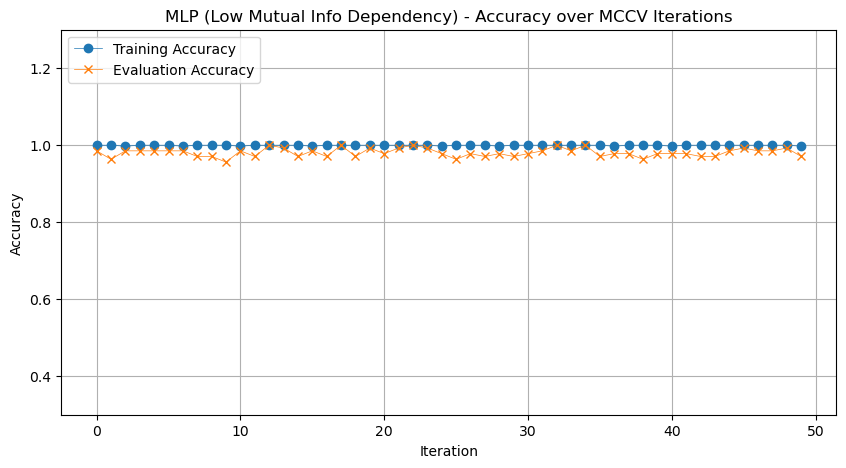

In [12]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("MLP (Low Mutual Info Dependency) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Log loss over MCCV iterations

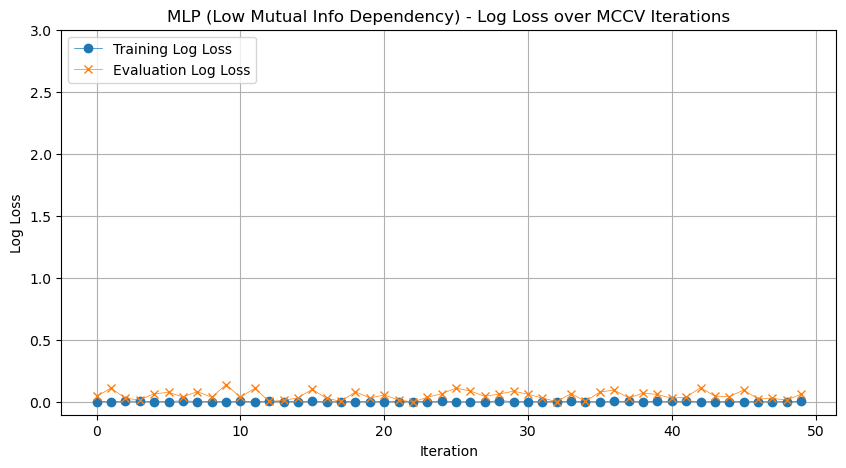

In [13]:
# Log loss over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Log Loss', marker='o', linewidth=0.5)
plt.plot(test_losses, label='Evaluation Log Loss', marker='x', linewidth=0.5)
plt.title("MLP (Low Mutual Info Dependency) - Log Loss over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(-0.1, 3.0)
plt.show()

### Plot the average confussion matrix

In [14]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title="MLP (Low Mutual Info Dependency) MCCV - Average Confusion Matrix", cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

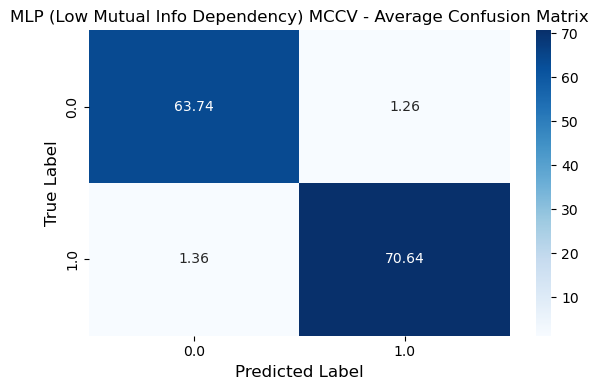

In [15]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [16]:
# End time
end_time = time.time()

### Elapsed time

In [17]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for MLP (Low Mutual Info Dependency): {elapsed_time:.2f} seconds")

Elapsed time for MLP (Low Mutual Info Dependency): 27.25 seconds
